In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("ggplot")

In [2]:
df = pd.read_csv(r"D:\mutual-fund-analysis\data\raw\scheme_performance.csv")

In [3]:
df.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
0,119551,SBI Bluechip Fund - Regular Plan - Growth,SBI Mutual Fund,Large Cap,Regular,12.42,12.36,14.45,11.49,0.87,0.89,0.88,1.29,14.0,-21.70,14288.0,1.54,4.0,Moderate
1,119552,SBI Bluechip Fund - Direct Plan - Growth,SBI Mutual Fund,Large Cap,Direct,15.25,11.30,14.23,9.52,1.78,0.87,0.81,1.29,14.0,-24.43,1231.0,0.66,3.0,Moderate
2,119598,SBI Small Cap Fund - Regular Plan - Growth,SBI Mutual Fund,Small Cap,Regular,24.56,23.39,20.67,22.16,1.23,0.89,0.94,1.35,25.0,-13.35,19259.0,1.43,5.0,Very High
3,119599,SBI Small Cap Fund - Direct Plan - Growth,SBI Mutual Fund,Small Cap,Direct,20.59,23.14,21.82,22.01,1.13,1.04,0.93,1.67,25.0,-24.78,36061.0,0.72,4.0,Very High
4,119120,SBI Magnum Gilt Fund - Regular Plan - Growth,SBI Mutual Fund,Gilt,Regular,5.34,6.07,5.43,4.47,1.60,0.22,1.52,2.11,4.0,-2.30,24101.0,0.77,5.0,Low


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 42 entries, 0 to 41
Data columns (total 19 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   amfi_code           41 non-null     object 
 1   scheme_name         41 non-null     object 
 2   fund_house          40 non-null     object 
 3   category            40 non-null     object 
 4   plan                40 non-null     object 
 5   return_1yr_pct      41 non-null     float64
 6   return_3yr_pct      40 non-null     float64
 7   return_5yr_pct      40 non-null     float64
 8   benchmark_3yr_pct   40 non-null     float64
 9   alpha               40 non-null     float64
 10  beta                40 non-null     float64
 11  sharpe_ratio        40 non-null     float64
 12  sortino_ratio       40 non-null     float64
 13  std_dev_ann_pct     40 non-null     float64
 14  max_drawdown_pct    40 non-null     float64
 15  aum_crore           41 non-null     float64
 16  expense_ra

In [5]:
df.describe()

,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating
count,41.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,4.100000e+01,41.000000,41.000000
mean,14.376000,14.089000,14.516750,12.835500,1.253500,0.873250,1.361750,2.082500,14.962500,-19.200250,5.091044e+04,1.237000,4.250000
std,4.821599,4.617253,4.454021,4.740972,0.447412,0.224846,1.475805,2.203144,6.669282,8.819164,1.595020e+05,0.381721,0.733144
min,4.260000,5.140000,5.430000,3.960000,0.510000,0.220000,0.800000,1.030000,0.500000,-33.500000,9.790000e+02,0.550000,3.000000
25%,11.820000,12.035000,12.340000,10.690000,0.887500,0.890000,0.865000,1.270000,14.000000,-25.062500,1.791200e+04,0.790000,4.000000
50%,14.420000,14.205000,14.185000,13.090000,1.205000,0.960000,0.925000,1.445000,14.000000,-20.600000,2.762300e+04,1.420000,4.000000
75%,16.300000,15.882500,17.585000,14.775000,1.700000,1.000000,0.985000,1.637500,19.000000,-14.255000,3.899500e+04,1.540000,5.000000
max,24.930000,23.390000,23.800000,22.160000,1.980000,1.040000,7.680000,10.370000,25.000000,-2.230000,1.043664e+06,1.640000,5.000000


In [6]:
df.shape

(42, 19)

In [7]:
df.isnull().sum()

amfi_code             1
scheme_name           1
fund_house            2
category              2
plan                  2
return_1yr_pct        1
return_3yr_pct        2
return_5yr_pct        2
benchmark_3yr_pct     2
alpha                 2
beta                  2
sharpe_ratio          2
sortino_ratio         2
std_dev_ann_pct       2
max_drawdown_pct      2
aum_crore             1
expense_ratio_pct     1
morningstar_rating    1
risk_grade            2
dtype: int64

In [8]:
print("Total Schemes:", df["scheme_name"].nunique())

Total Schemes: 41


In [9]:
print("Total AUM:", df["aum_crore"].sum())

Total AUM: 2087328.0


In [10]:
print("Average 3-Year Return:", round(df["return_3yr_pct"].mean(),2))

Average 3-Year Return: 14.09


In [11]:
print("Average Expense Ratio:", round(df["expense_ratio_pct"].mean(),2))

Average Expense Ratio: 1.24


Week 1 – Python for Data Analysis (Visualizations)

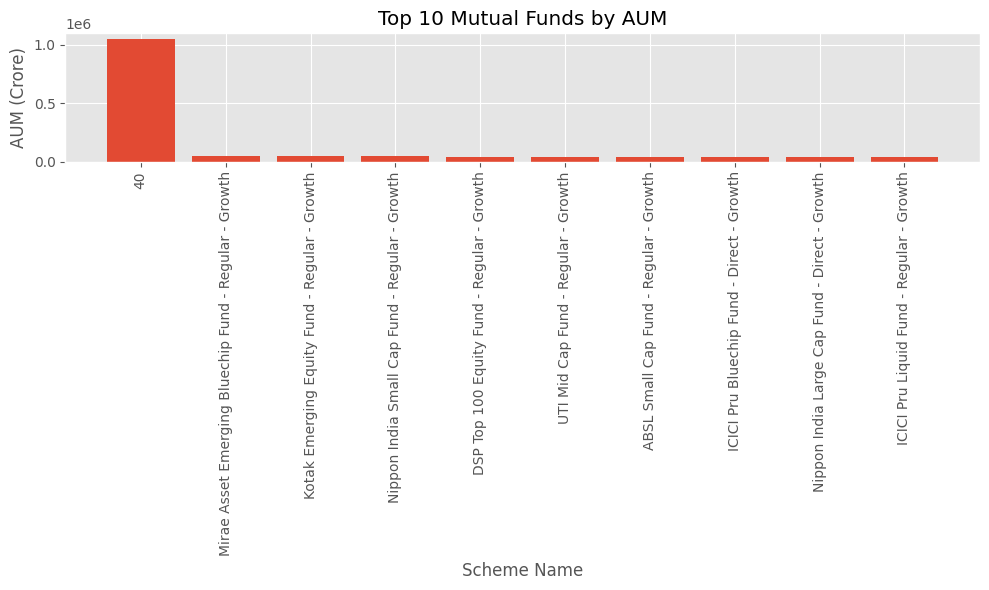

In [12]:
#Top 10 Funds by AUM
top10 = df.sort_values(by="aum_crore", ascending=False).head(10)

plt.figure(figsize=(10,6))
plt.bar(top10["scheme_name"], top10["aum_crore"])
plt.xticks(rotation=90)
plt.title("Top 10 Mutual Funds by AUM")
plt.xlabel("Scheme Name")
plt.ylabel("AUM (Crore)")
plt.tight_layout()
plt.show()

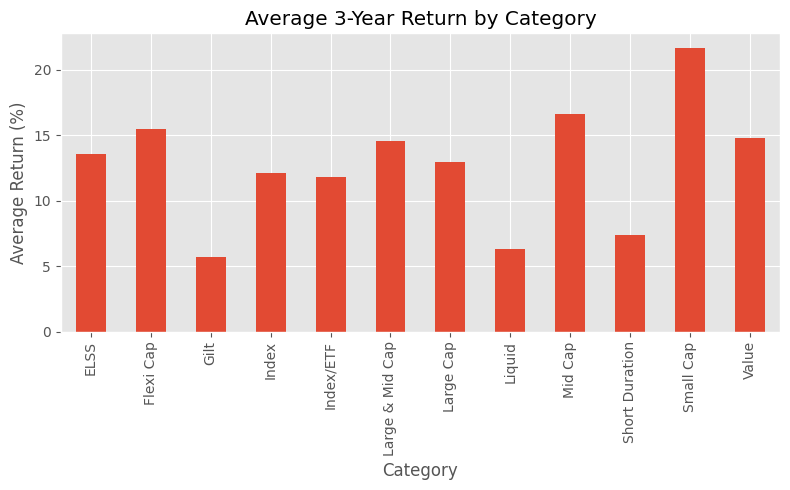

In [13]:
#Average Return by Category
category_return = df.groupby("category")["return_3yr_pct"].mean()

plt.figure(figsize=(8,5))
category_return.plot(kind="bar")
plt.title("Average 3-Year Return by Category")
plt.xlabel("Category")
plt.ylabel("Average Return (%)")
plt.tight_layout()
plt.show()

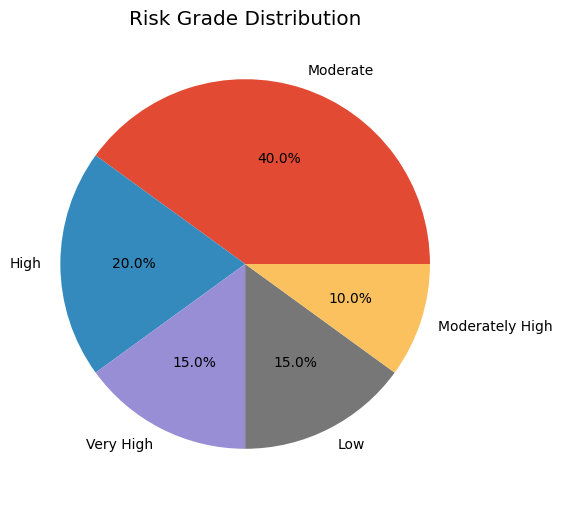

In [14]:
#Risk Grade Distribution
risk = df["risk_grade"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(risk, labels=risk.index, autopct="%1.1f%%")
plt.title("Risk Grade Distribution")
plt.show()

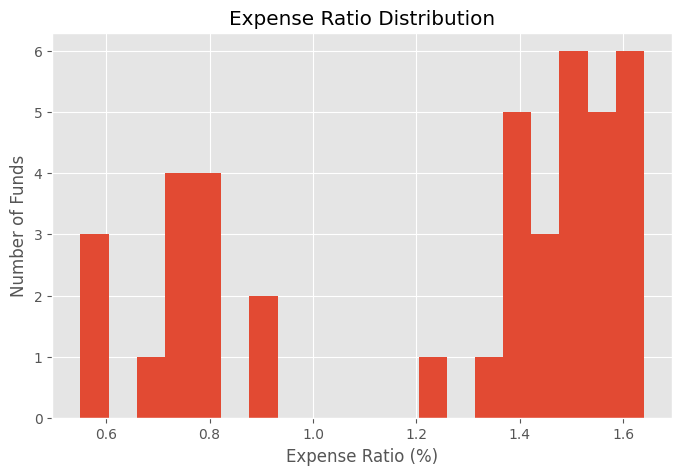

In [15]:
#Distribution of Expense Ratio
plt.figure(figsize=(8,5))
plt.hist(df["expense_ratio_pct"], bins=20)
plt.title("Expense Ratio Distribution")
plt.xlabel("Expense Ratio (%)")
plt.ylabel("Number of Funds")
plt.show()

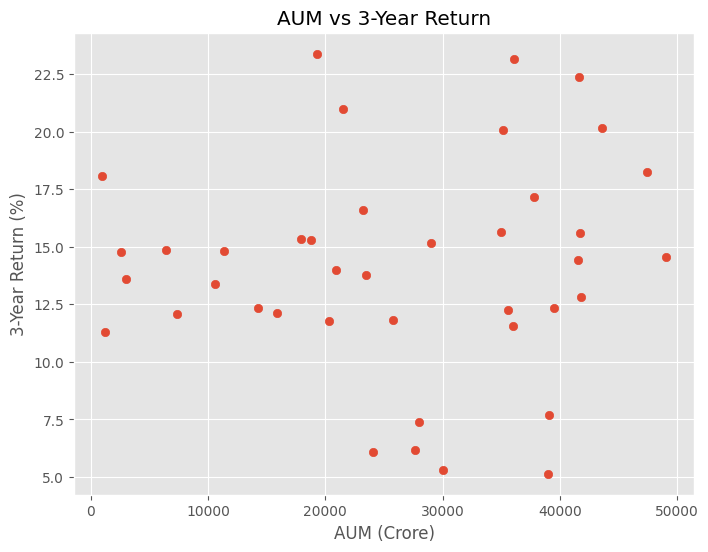

In [16]:
#AUM vs 3-Year Return
plt.figure(figsize=(8,6))
plt.scatter(df["aum_crore"], df["return_3yr_pct"])
plt.title("AUM vs 3-Year Return")
plt.xlabel("AUM (Crore)")
plt.ylabel("3-Year Return (%)")
plt.show()

In [20]:
#Save the Cleaned Dataset
df.to_csv(r"D:\mutual-fund-analysis\data\processed\cleaned_scheme_performance.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


Business Insights

• The top 10 mutual funds contribute a significant share of total AUM.
• Large Cap funds have stable average returns compared to other categories.
• Moderate and High risk funds represent the majority of available schemes.
• Expense ratios vary across fund houses, which can affect investor returns.
• Some funds deliver high returns despite maintaining relatively lower expense ratios.